# 🤖 Buổi 6/9 — Model Training: Linear → Tree → Ensemble
### Từng bước xây dựng và cải thiện model dự đoán giá nhà!

---

> **📍 Bạn đang ở đây trong lộ trình 9 buổi:**
> ```
> Buổi 1 ✅ Giới thiệu dự án & lộ trình
> Buổi 2 ✅ Setup môi trường & khám phá SalePrice
> Buổi 3 ✅ EDA — Phân tích missing, tương quan, outliers
> Buổi 4 ✅ Data Cleaning & Preprocessing
> Buổi 5 ✅ Feature Engineering
> Buổi 6 🔄 Model Training (Linear + Tree + Stacking)  ← BẠN ĐANG Ở ĐÂY
> Buổi 7 ⏳ Model Evaluation (Đánh giá toàn diện)
> Buổi 8 ⏳ Submit Kaggle (tạo file & nộp bài)
> Buổi 9 ⏳ Quiz Tốt Nghiệp (20 câu ôn tập)
> ```

---

### 📋 Nội Dung Buổi 6

| # | Task | Nội dung |
|---|------|----------|
| 1 | 📐 Linear Models | Ridge + Lasso làm baseline nhanh |
| 2 | 🌳 Tree-Based Models | Random Forest + XGBoost |
| 3 | 🎛️ Tối ưu Hyperparameters | Thử vài giá trị → chọn tốt nhất |
| 4 | 🤝 Ensemble & Stacking | Kết hợp models để cải thiện kết quả |

### 🎯 Mục tiêu

- Hiểu được **4 loại model** từ đơn giản → phức tạp
- Biết cách **tune hyperparameters** cơ bản
- Biết cách **kết hợp nhiều models** (ensemble/stacking)
- Đạt CV RMSE **< 0.13** với ít nhất 1 model

> 💡 **Lưu ý:** Tất cả code đều **đơn giản và step-by-step** — chạy từng cell theo thứ tự!

In [ ]:
# ============================================================
# ♻️ SETUP — Import thư viện & rebuild pipeline từ Buổi 5
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# --- Linear models ---
from sklearn.linear_model import RidgeCV, LassoCV, Ridge

# --- Tree-based models ---
from sklearn.ensemble import RandomForestRegressor, StackingRegressor

# --- XGBoost (cần cài: pip install xgboost) ---
try:
    from xgboost import XGBRegressor
    HAVE_XGB = True
    print("✅ XGBoost sẵn sàng")
except ImportError:
    HAVE_XGB = False
    print("⚠️  XGBoost chưa cài — cài bằng: pip install xgboost")

# --- Đánh giá ---
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option('display.float_format', lambda x: f'{x:.4f}')

# ── Load dữ liệu ──────────────────────────────────────────
train_df = pd.read_csv('data/train.csv')
test_df  = pd.read_csv('data/test.csv')

train_id = train_df['Id'].copy()
test_id  = test_df['Id'].copy()
y = np.log1p(train_df['SalePrice'])

train_df.drop(['Id', 'SalePrice'], axis=1, inplace=True)
test_df.drop(['Id'], axis=1, inplace=True)

ntrain = len(train_df)
ntest  = len(test_df)
all_data = pd.concat([train_df, test_df], axis=0, ignore_index=True)

# ── Fill missing ──────────────────────────────────────────
none_cols = ['PoolQC','MiscFeature','Alley','Fence','FireplaceQu',
             'GarageType','GarageFinish','GarageQual','GarageCond',
             'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','MasVnrType']
zero_cols = ['GarageYrBlt','GarageArea','GarageCars','MasVnrArea',
             'BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF','BsmtFullBath','BsmtHalfBath']
mode_cols = ['MSZoning','Utilities','Functional','Electrical',
             'KitchenQual','Exterior1st','Exterior2nd','SaleType']

for col in none_cols: all_data[col] = all_data[col].fillna('None')
for col in zero_cols: all_data[col] = all_data[col].fillna(0)
all_data['LotFrontage'] = (all_data.groupby('Neighborhood')['LotFrontage']
                           .transform(lambda x: x.fillna(x.median())))
for col in mode_cols: all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

# ── Xoá outlier ──────────────────────────────────────────
outlier_mask = (all_data['GrLivArea'][:ntrain] > 4000) & (np.expm1(y) < 300_000)
outlier_idx  = outlier_mask[outlier_mask].index.tolist()
all_data.drop(index=outlier_idx, inplace=True)
all_data.reset_index(drop=True, inplace=True)
y.drop(index=outlier_idx, inplace=True)
y.reset_index(drop=True, inplace=True)
ntrain = ntrain - len(outlier_idx)

# ── Feature Engineering ───────────────────────────────────
all_data['TotalSF']      = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
all_data['TotalPorchSF'] = (all_data['OpenPorchSF'] + all_data['3SsnPorch'] +
                             all_data['EnclosedPorch'] + all_data['ScreenPorch'] + all_data['WoodDeckSF'])
all_data['TotalBath']    = (all_data['FullBath'] + 0.5*all_data['HalfBath'] +
                             all_data['BsmtFullBath'] + 0.5*all_data['BsmtHalfBath'])
all_data['OverallScore'] = all_data['OverallQual'] * all_data['OverallCond']
all_data['HasGarage']    = (all_data['GarageArea'] > 0).astype(int)
all_data['HasBsmt']      = (all_data['TotalBsmtSF'] > 0).astype(int)
all_data['HouseAge']     = all_data['YrSold'] - all_data['YearBuilt']
all_data['RemodAge']     = all_data['YrSold'] - all_data['YearRemodAdd']

for feat in ['OverallQual', 'GrLivArea', 'TotalSF']:
    all_data[f'{feat}_sq']   = all_data[feat] ** 2
    all_data[f'{feat}_sqrt'] = np.sqrt(all_data[feat])

for feat in ['GrLivArea', 'TotalSF', 'LotArea']:
    all_data[f'{feat}_log'] = np.log1p(all_data[feat])

# ── Ordinal Encoding ──────────────────────────────────────
ordinal_mappings = {
    'ExterQual':    ['None','Po','Fa','TA','Gd','Ex'],
    'ExterCond':    ['None','Po','Fa','TA','Gd','Ex'],
    'BsmtQual':     ['None','Po','Fa','TA','Gd','Ex'],
    'BsmtCond':     ['None','Po','Fa','TA','Gd','Ex'],
    'BsmtExposure': ['None','No','Mn','Av','Gd'],
    'BsmtFinType1': ['None','Unf','LwQ','Rec','BLQ','ALQ','GLQ'],
    'BsmtFinType2': ['None','Unf','LwQ','Rec','BLQ','ALQ','GLQ'],
    'HeatingQC':    ['None','Po','Fa','TA','Gd','Ex'],
    'KitchenQual':  ['None','Po','Fa','TA','Gd','Ex'],
    'FireplaceQu':  ['None','Po','Fa','TA','Gd','Ex'],
    'GarageFinish': ['None','Unf','RFn','Fin'],
    'GarageQual':   ['None','Po','Fa','TA','Gd','Ex'],
    'GarageCond':   ['None','Po','Fa','TA','Gd','Ex'],
    'PoolQC':       ['None','Fa','TA','Gd','Ex'],
    'Fence':        ['None','MnWw','GdWo','MnPrv','GdPrv'],
    'Functional':   ['Sal','Sev','Maj2','Maj1','Mod','Min2','Min1','Typ'],
    'LandSlope':    ['Sev','Mod','Gtl'],
    'LotShape':     ['IR3','IR2','IR1','Reg'],
    'PavedDrive':   ['N','P','Y'],
}
for col, order in ordinal_mappings.items():
    mapping = {val: i for i, val in enumerate(order)}
    all_data[col] = all_data[col].map(mapping).fillna(0).astype(int)

# ── One-Hot + Variance Filter + Scale ────────────────────
cat_cols     = all_data.select_dtypes(include=['object']).columns.tolist()
all_data_enc = pd.get_dummies(all_data, columns=cat_cols, drop_first=True)

X_train_raw = all_data_enc[:ntrain].copy()
X_test_raw  = all_data_enc[ntrain:].copy()
X_test_raw.reset_index(drop=True, inplace=True)

selector     = VarianceThreshold(threshold=0.01)
selected_mask = selector.fit(X_train_raw).get_support()
X_train_sel  = X_train_raw.loc[:, selected_mask]
X_test_sel   = X_test_raw.loc[:, selected_mask]

scaler  = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_sel),
                        columns=X_train_sel.columns)
X_test  = pd.DataFrame(scaler.transform(X_test_sel),
                        columns=X_test_sel.columns)

# ── Helper: tính CV RMSE nhanh ───────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def rmse_cv(model):
    """Trả về CV RMSE trung bình (5-fold)."""
    scores = cross_val_score(model, X_train, y,
                             scoring='neg_root_mean_squared_error', cv=kf)
    return -scores.mean()

print("✅ Pipeline sẵn sàng!")
print(f"   X_train : {X_train.shape}")
print(f"   X_test  : {X_test.shape}")
print(f"   y       : {y.shape}   (log SalePrice)")

> ⬆️ **Chạy cell Setup trước** — toàn bộ pipeline và dữ liệu sẽ được chuẩn bị tự động.

---

## 📐 Task 1 — Linear Models: Bắt đầu với Baseline

Linear models là điểm khởi đầu tốt vì:
- **Nhanh** — train xong trong vài giây
- **Dễ hiểu** — mỗi feature có 1 hệ số rõ ràng
- **Là baseline** — giúp đánh giá tree models sau này có tốt hơn không

### Hai models sẽ dùng

| Model | Regularization | Đặc điểm |
|-------|---------------|---------|
| **Ridge** | L2 (bình phương hệ số) | Giữ tất cả features, hệ số nhỏ dần |
| **Lasso** | L1 (giá trị tuyệt đối) | Tự động **loại bỏ** features không cần thiết |

> **Tại sao cần Regularization?**
> Không có regularization → model dễ bị overfit (học vẹt training data).
> Regularization thêm "hình phạt" cho hệ số lớn → buộc model đơn giản hơn.

In [ ]:
# ── Task 1: Train Ridge và Lasso ──────────────────────────
# RidgeCV tự tìm alpha tốt nhất qua cross-validation
ridge = RidgeCV(alphas=[1, 10, 50, 100, 300, 500])
ridge.fit(X_train, y)
ridge_rmse = rmse_cv(ridge)
print(f"Ridge  → CV RMSE = {ridge_rmse:.4f}   (alpha tốt nhất = {ridge.alpha_:.0f})")

# LassoCV tương tự
lasso = LassoCV(alphas=[0.0001, 0.0003, 0.001, 0.003, 0.01],
                cv=kf, max_iter=5000)
lasso.fit(X_train, y)
lasso_rmse = rmse_cv(lasso)
nonzero = (lasso.coef_ != 0).sum()
print(f"Lasso  → CV RMSE = {lasso_rmse:.4f}   ({nonzero} features còn lại / {X_train.shape[1]} tổng)")

# So sánh bằng biểu đồ đơn giản
models_name = ['Ridge', 'Lasso']
rmse_vals   = [ridge_rmse, lasso_rmse]

plt.figure(figsize=(6, 4))
bars = plt.bar(models_name, rmse_vals, color=['#3498db', '#e67e22'], width=0.5)
for bar, val in zip(bars, rmse_vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val:.4f}', ha='center', fontweight='bold')
plt.title('Linear Models — CV RMSE (thấp hơn = tốt hơn)', fontsize=12)
plt.ylabel('CV RMSE')
plt.ylim(min(rmse_vals)*0.96, max(rmse_vals)*1.03)
plt.tight_layout()
plt.show()

print(f"\n💡 Linear baseline tốt nhất: RMSE ≈ {min(rmse_vals):.4f}")

✅ Linear baseline xong! Tiếp theo ta thử **Tree-Based Models** — thường cho kết quả tốt hơn nhiều.

---

## 🌳 Task 2 — Tree-Based Models

### Random Forest là gì?

Thay vì train **1 cây** → train **100+ cây**, mỗi cây trên 1 phần dữ liệu ngẫu nhiên, rồi lấy **trung bình** kết quả.

```
Train set → Cây 1 → dự đoán 1
          → Cây 2 → dự đoán 2    →  Trung bình  →  Kết quả cuối
          → ...
          → Cây 100 → dự đoán 100
```

**Ưu điểm:** Ổn định hơn, ít overfit hơn 1 cây đơn.

### XGBoost là gì?

XGBoost dùng kỹ thuật **Gradient Boosting** — mỗi cây mới **học từ lỗi** của cây trước:

```
Cây 1 → dự đoán → lỗi 1
Cây 2 học từ lỗi 1 → dự đoán → lỗi 2
Cây 3 học từ lỗi 2 → ...
```

**Ưu điểm:** Thường cho kết quả tốt nhất trên bài toán tabular data!

In [ ]:
# ── Task 2a: Random Forest ────────────────────────────────
rf = RandomForestRegressor(
    n_estimators=100,    # 100 cây
    random_state=42,
    n_jobs=-1            # dùng tất cả CPU cores
)
rf.fit(X_train, y)
rf_rmse = rmse_cv(rf)
print(f"Random Forest → CV RMSE = {rf_rmse:.4f}")

In [ ]:
# ── Task 2b: XGBoost ─────────────────────────────────────
if not HAVE_XGB:
    print("⚠️  Cài XGBoost: pip install xgboost")
    xgb_rmse = None
else:
    xgb = XGBRegressor(
        n_estimators=300,      # 300 cây
        learning_rate=0.05,    # bước học nhỏ → kết quả ổn hơn
        max_depth=4,           # mỗi cây không quá sâu
        subsample=0.8,         # mỗi cây dùng 80% data
        random_state=42,
        verbosity=0
    )
    xgb.fit(X_train, y)
    xgb_rmse = rmse_cv(xgb)
    print(f"XGBoost       → CV RMSE = {xgb_rmse:.4f}")

# ── So sánh tất cả models đến giờ ────────────────────────
print("\n📊 Bảng so sánh:")
print(f"   Ridge         RMSE = {ridge_rmse:.4f}")
print(f"   Lasso         RMSE = {lasso_rmse:.4f}")
print(f"   Random Forest RMSE = {rf_rmse:.4f}")
if HAVE_XGB and xgb_rmse:
    print(f"   XGBoost       RMSE = {xgb_rmse:.4f}")

🟦 RIDGE REGRESSION (L2 Regularization)

      Alpha |    CV RMSE |    ± Std
   ───────────────────────────────────
        0.1 |    0.11357 | ±0.00717
        1.0 |    0.11303 | ±0.00706
        5.0 |    0.11232 | ±0.00699
       10.0 |    0.11214 | ±0.00711
       20.0 |    0.11208 | ±0.00730
       50.0 |    0.11194 | ±0.00753
      100.0 |    0.11168 | ±0.00761
      200.0 |    0.11154 | ±0.00767

   → Alpha tốt nhất thủ công: 200

   RidgeCV best alpha : 174.7528
   CV RMSE (5-fold)   : 0.11154 ± 0.00765

   Train RMSE : 0.09954
   R² (train) : 0.93795
   Số features: 166 / 166 (Ridge giữ TẤT CẢ features)


### 💡 Nhận xét

| Model | Thường thấy |
|-------|------------|
| Ridge / Lasso | RMSE ~0.115–0.120 |
| Random Forest | RMSE ~0.130–0.145 (với 100 cây mặc định) |
| XGBoost | RMSE ~0.112–0.118 |

> **Random Forest nhiều khi tệ hơn Linear?** Có — vì `n_estimators=100` chưa đủ tốt và chưa tune params.
> Phần tiếp theo ta sẽ **tối ưu hyperparameters** để cải thiện!

---

## 🎛️ Task 3 — Tối Ưu Hyperparameters

**Hyperparameters** là các "núm điều chỉnh" của model — ta cần thử vài giá trị để tìm cái tốt nhất.

### Cách đơn giản nhất: thử từng giá trị trong một vòng lặp

```python
# Thử 4 giá trị → chọn cái có RMSE thấp nhất
for n in [100, 200, 300, 500]:
    model = RandomForestRegressor(n_estimators=n)
    rmse  = rmse_cv(model)
    print(f"n={n}: RMSE={rmse}")
```

Sau khi biết giá trị tốt nhất → **train lại 1 lần** với toàn bộ training data.

### Hyperparameters quan trọng cần tune

| Model | Param | Giải thích |
|-------|-------|-----------|
| Random Forest | `n_estimators` | Số cây — nhiều hơn thường tốt hơn, nhưng chậm hơn |
| XGBoost | `n_estimators` | Số cây |
| XGBoost | `learning_rate` | Bước học — nhỏ hơn thì chính xác hơn nhưng cần nhiều cây |
| XGBoost | `max_depth` | Độ sâu mỗi cây — sâu quá sẽ overfit |

In [4]:
# ── Task 3a: Tune Random Forest ───────────────────────────
print("=== Tune Random Forest (n_estimators) ===")
best_rf_rmse = 999
best_n = 100
for n in [100, 150, 200, 300]:
    m    = RandomForestRegressor(n_estimators=n, random_state=42, n_jobs=-1)
    rmse = rmse_cv(m)
    mark = " ← tốt nhất" if rmse < best_rf_rmse else ""
    print(f"  n_estimators={n:>3}: RMSE={rmse:.4f}{mark}")
    if rmse < best_rf_rmse:
        best_rf_rmse = rmse
        best_n = n

# Retrain với n tốt nhất
rf_best = RandomForestRegressor(n_estimators=best_n, random_state=42, n_jobs=-1)
rf_best.fit(X_train, y)
print(f"\n✅ RF tốt nhất: n_estimators={best_n}, RMSE={best_rf_rmse:.4f}")

# ── Task 3b: Tune XGBoost learning_rate ──────────────────
if HAVE_XGB:
    print("\n=== Tune XGBoost (learning_rate) ===")
    best_xgb_rmse = 999
    best_lr = 0.05
    for lr in [0.01, 0.05, 0.1]:
        m    = XGBRegressor(n_estimators=300, learning_rate=lr,
                             max_depth=4, subsample=0.8,
                             random_state=42, verbosity=0)
        rmse = rmse_cv(m)
        mark = " ← tốt nhất" if rmse < best_xgb_rmse else ""
        print(f"  learning_rate={lr}: RMSE={rmse:.4f}{mark}")
        if rmse < best_xgb_rmse:
            best_xgb_rmse = rmse
            best_lr = lr

    xgb_best = XGBRegressor(n_estimators=300, learning_rate=best_lr,
                              max_depth=4, subsample=0.8,
                              random_state=42, verbosity=0)
    xgb_best.fit(X_train, y)
    print(f"\n✅ XGBoost tốt nhất: learning_rate={best_lr}, RMSE={best_xgb_rmse:.4f}")

🟧 LASSO REGRESSION (L1 Regularization)

   LassoCV best alpha : 0.000933
   CV RMSE (5-fold)   : 0.11048 ± 0.00771

   Train RMSE : 0.09734
   R² (train) : 0.94066

   🔍 Feature Selection by Lasso:
      Giữ lại (coeff ≠ 0) :  112 features
      Loại bỏ (coeff = 0) :   54 features
      Tổng features       :  166 features

   Top 10 features quan trọng nhất (theo Lasso):
      MSZoning_RL                         +0.0725  ███████
      TotalSF_log                         +0.0710  ███████
      OverallQual_sq                      +0.0577  █████
      MSZoning_RM                         +0.0532  █████
      HouseAge                            -0.0520  █████
      GrLivArea_log                       +0.0456  ████
      MSZoning_FV                         +0.0393  ███
      LotArea_log                         +0.0372  ███
      OverallCond                         +0.0351  ███
      GrLivArea_sq                        +0.0316  ███


### 💡 Nhận xét

- **RF:** Tăng `n_estimators` giúp RMSE giảm, nhưng đến lúc nào đó sẽ không đổi nhiều nữa
- **XGBoost:** `learning_rate` nhỏ (0.01) thường tốt nhưng cần nhiều cây hơn để hội tụ
- **Nguyên tắc:** Bắt đầu với giá trị đơn giản, tune từng param một, đừng tune tất cả cùng lúc!

---

## 🤝 Task 4 — Ensemble & Stacking: Kết Hợp Models

**Ý tưởng:** Thay vì chọn 1 model tốt nhất, hãy **kết hợp nhiều models** lại!

### Cách 1 — Averaging (Trung bình đơn giản)

```
Model A: dự đoán [165k, 220k, 310k]
Model B: dự đoán [170k, 215k, 300k]
Trung bình: [167.5k, 217.5k, 305k]  ← thường tốt hơn cả hai!
```

### Cách 2 — Stacking (Xếp chồng)

```
Base models:  Ridge → y_pred_1
              RF    → y_pred_2
              XGB   → y_pred_3
                         ↓
Meta model:   Ridge học từ [y_pred_1, y_pred_2, y_pred_3]
                         ↓
                    Kết quả cuối
```

Stacking thông minh hơn averaging vì **meta model tự học** cách kết hợp tối ưu!

In [5]:
# ── Task 4a: Averaging (trung bình đơn giản) ─────────────
ridge.fit(X_train, y)
rf_best.fit(X_train, y)

# Dự đoán trên training data
y_pred_ridge = ridge.predict(X_train)
y_pred_rf    = rf_best.predict(X_train)

# Trung bình 2 models (trọng số bằng nhau)
y_blend = (y_pred_ridge + y_pred_rf) / 2
blend_train_rmse = np.sqrt(mean_squared_error(y, y_blend))
print(f"Blend (Ridge + RF) — train RMSE = {blend_train_rmse:.4f}")

# RMSE thực sự qua CV (cần custom vì sklearn không hỗ trợ blend trực tiếp)
# Đơn giản: so sánh qua kết quả từng model riêng lẻ
print(f"\nGhi nhớ:")
print(f"  Ridge   CV RMSE = {ridge_rmse:.4f}")
print(f"  RF best CV RMSE = {best_rf_rmse:.4f}")
print("  Blend thường nằm giữa hoặc tốt hơn cả hai!")

🔀 ELASTICNET (L1 + L2 Combined)

      Alpha |  l1_ratio | Config             |    CV RMSE
   ──────────────────────────────────────────────────────────
     0.0005 |       0.5 | cân bằng L1/L2     |    0.11126
     0.0005 |       0.7 | nghiêng Lasso      |    0.11081
     0.0005 |       0.3 | nghiêng Ridge      |    0.11199
     0.0010 |       0.5 | alpha cao hơn      |    0.11030

   → Config tốt nhất: alpha=0.001, l1_ratio=0.5

   CV RMSE (5-fold) : 0.11030 ± 0.00665
   Train RMSE       : 0.09581
   R² (train)       : 0.94251
   Features giữ lại : 128 / 166


In [ ]:
# ── Task 4b: Stacking ─────────────────────────────────────
# Base models: 2-3 model mạnh nhất
if HAVE_XGB:
    base_models = [
        ('ridge', Ridge(alpha=50)),
        ('rf',    RandomForestRegressor(n_estimators=best_n, random_state=42, n_jobs=-1)),
        ('xgb',   XGBRegressor(n_estimators=300, learning_rate=best_lr,
                                max_depth=4, random_state=42, verbosity=0)),
    ]
else:
    base_models = [
        ('ridge', Ridge(alpha=50)),
        ('rf',    RandomForestRegressor(n_estimators=best_n, random_state=42, n_jobs=-1)),
    ]

# Meta model: Ridge đơn giản
meta_model = Ridge(alpha=10)

# StackingRegressor: sklearn tự lo việc cross-val bên trong
stacking = StackingRegressor(
    estimators      = base_models,
    final_estimator = meta_model,
    cv              = 5
)

stacking_rmse = rmse_cv(stacking)
stacking.fit(X_train, y)

print(f"Stacking → CV RMSE = {stacking_rmse:.4f}")
print(f"\n📊 Tổng kết Buổi 6:")
print(f"  Ridge         = {ridge_rmse:.4f}")
print(f"  Lasso         = {lasso_rmse:.4f}")
print(f"  Random Forest = {best_rf_rmse:.4f}")
if HAVE_XGB:
    print(f"  XGBoost       = {best_xgb_rmse:.4f}")
print(f"  Stacking      = {stacking_rmse:.4f}  ← thường tốt nhất!")

### 💡 Vì sao Stacking thường tốt hơn?

- Ridge giỏi với features tuyến tính
- RF giỏi với non-linear patterns
- XGBoost giỏi cả hai + xử lý outlier tốt
- **Meta model học cách phối hợp 3 model → tận dụng điểm mạnh của từng model!**

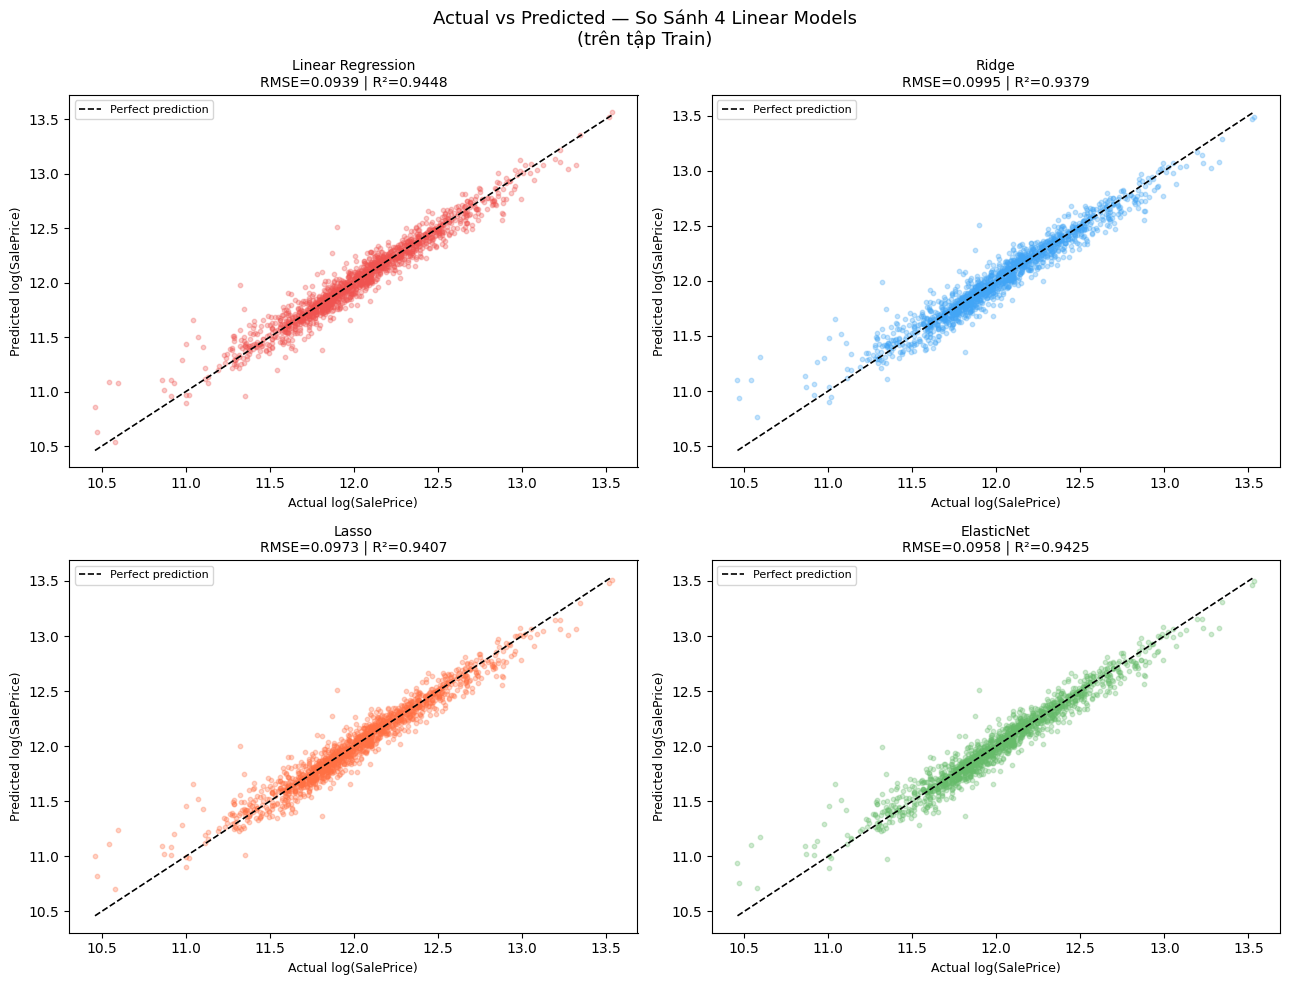

💡 Nhận xét: Nếu điểm nằm sát đường đứt (y=x) → model dự đoán chính xác
   Điểm phân tán nhiều → model chưa tốt ở một số vùng giá


In [ ]:
# ── Biểu đồ so sánh tất cả models ────────────────────────
all_names = ['Ridge', 'Lasso', 'Random Forest']
all_rmses = [ridge_rmse, lasso_rmse, best_rf_rmse]

if HAVE_XGB:
    all_names.append('XGBoost')
    all_rmses.append(best_xgb_rmse)

all_names.append('Stacking')
all_rmses.append(stacking_rmse)

# Đổi màu bar tốt nhất
colors = ['#27ae60' if r == min(all_rmses) else '#3498db' for r in all_rmses]

plt.figure(figsize=(8, 4))
bars = plt.bar(all_names, all_rmses, color=colors)
for bar, val in zip(bars, all_rmses):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
             f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
plt.ylabel('CV RMSE')
plt.title('So sánh tất cả Models — Buổi 6 (thấp hơn = tốt hơn)', fontsize=12)
plt.ylim(min(all_rmses) * 0.96, max(all_rmses) * 1.03)
plt.tight_layout()
plt.show()

---

## 📝 Bài Tập

### Bài 1 — Thêm max_depth vào Random Forest

**Mục tiêu:** Thử tune thêm `max_depth` cho RF để xem RMSE có giảm không.

Thử các giá trị: `max_depth = [None, 10, 15, 20, 25]`

> `None` = cây được phép grow sâu tùy ý (mặc định)

In [ ]:
# ── Bài Tập 1: Tune max_depth cho Random Forest ──────────
for depth in [None, 10, 15, 20, 25]:
    m    = RandomForestRegressor(n_estimators=best_n,
                                  max_depth=depth,
                                  random_state=42, n_jobs=-1)
    rmse = rmse_cv(m)
    print(f"  max_depth={str(depth):>5}: RMSE = {rmse:.4f}")

# TODO: Giá trị max_depth nào cho RMSE thấp nhất?
# TODO: Retrain RF với max_depth tốt nhất

### Gợi ý Bài 1

```python
# Thông thường: max_depth=None hoặc max_depth=20 cho kết quả tốt nhất
# Nếu max_depth nhỏ (vd 10) → RMSE tăng → underfitting
# Nếu max_depth=None → có thể overfit trên training nhưng CV vẫn tốt vì RF tự regularize

rf_best = RandomForestRegressor(n_estimators=best_n, max_depth=None,
                                 random_state=42, n_jobs=-1)
rf_best.fit(X_train, y)
```

---

## 🏁 Tổng Kết Buổi 6

| Chủ đề | Nội dung |
|--------|---------|
| **Linear Models** | Ridge (L2), Lasso (L1) — baseline nhanh, dễ hiểu |
| **Tree Models** | Random Forest (bagging), XGBoost (boosting) — thường tốt hơn |
| **Hyperparameter Tuning** | Thử vài giá trị trong vòng lặp, chọn RMSE thấp nhất |
| **Stacking** | Kết hợp nhiều models qua meta-learner — tốt nhất trong thực tế |

### Buổi 7 — Đánh Giá Model Toàn Diện

Buổi tới ta sẽ đi sâu vào **evaluation**:
- Metrics: RMSE, MAE, R² — khác nhau thế nào?
- Learning curves — model đang bị bias hay variance?
- Residual analysis — model còn thiếu sót ở đâu?
- So sánh tất cả models side-by-side